In [ ]:
# ============================================================
# Google Drive의 real_emotion_dataset.zip
# → Colab 로컬로 복사
# → 압축 해제
# → train / val / test 경로 자동 설정
# ============================================================


# ============================================================
# 1. Google Drive 연결
# ============================================================

from google.colab import drive

drive.mount('/content/drive')


# ============================================================
# 2. 라이브러리
# ============================================================

import os
import shutil
import zipfile


# ============================================================
# 3. 경로 설정
# ============================================================

# Google Drive에 있는 원본 ZIP 파일
SOURCE_ZIP = "/content/drive/MyDrive/real_emotion_dataset.zip"

# Colab 로컬에 복사할 ZIP
LOCAL_ZIP = "/content/real_emotion_dataset.zip"

# 압축을 풀 위치
EXTRACT_DIR = "/content/real_emotion_dataset"


# ============================================================
# 4. ZIP 파일 존재 확인
# ============================================================

if not os.path.exists(SOURCE_ZIP):

    raise FileNotFoundError(
        f"ZIP 파일을 찾을 수 없습니다.\n"
        f"확인 경로: {SOURCE_ZIP}"
    )

print("ZIP 파일 확인 완료")
print("원본:", SOURCE_ZIP)


# ============================================================
# 5. Google Drive → Colab 로컬 복사
#
# Drive에서 직접 압축 해제하면
# Transport endpoint is not connected 오류가 발생할 수 있으므로
# 먼저 /content로 복사한다.
# ============================================================

print("\nZIP 파일을 Colab 로컬로 복사 중...")


# 이미 이전 실행에서 파일이 있다면 삭제
if os.path.exists(LOCAL_ZIP):
    os.remove(LOCAL_ZIP)


shutil.copy2(
    SOURCE_ZIP,
    LOCAL_ZIP
)


print("로컬 복사 완료")
print("복사 위치:", LOCAL_ZIP)


# ============================================================
# 6. 기존 압축 해제 폴더 삭제
#
# Notebook을 다시 실행했을 때
# 기존 파일과 섞이는 것을 방지한다.
# ============================================================

if os.path.exists(EXTRACT_DIR):

    print("\n기존 압축 해제 폴더 삭제 중...")

    shutil.rmtree(EXTRACT_DIR)


os.makedirs(
    EXTRACT_DIR,
    exist_ok=True
)


# ============================================================
# 7. ZIP 압축 해제
# ============================================================

print("\nZIP 압축 해제 중...")


with zipfile.ZipFile(
    LOCAL_ZIP,
    "r"
) as zip_ref:

    zip_ref.extractall(
        EXTRACT_DIR
    )


print("압축 해제 완료")
print("압축 해제 위치:", EXTRACT_DIR)


# ============================================================
# 8. 압축 해제된 최상위 파일 확인
# ============================================================

print("\n압축 해제된 폴더:")

for item in os.listdir(EXTRACT_DIR):
    print(" -", item)


# ============================================================
# 9. 데이터셋 ROOT 자동 탐색
#
# ZIP 구조가
#
# real_emotion_dataset.zip
# └── train/
#
# 일 수도 있고
#
# real_emotion_dataset.zip
# └── real_emotion_dataset/
#     └── train/
#
# 형태일 수도 있기 때문에 자동 탐색한다.
# ============================================================


def find_dataset_root(base_dir):

    # --------------------------------------------------------
    # 경우 1
    #
    # /content/real_emotion_dataset/train
    # /content/real_emotion_dataset/val
    # /content/real_emotion_dataset/test
    # --------------------------------------------------------

    if (
        os.path.isdir(
            os.path.join(base_dir, "train")
        )
        and
        os.path.isdir(
            os.path.join(base_dir, "val")
        )
        and
        os.path.isdir(
            os.path.join(base_dir, "test")
        )
    ):

        return base_dir


    # --------------------------------------------------------
    # 경우 2
    #
    # 한 단계 안쪽에 dataset 폴더가 존재
    # --------------------------------------------------------

    for item in os.listdir(base_dir):

        candidate = os.path.join(
            base_dir,
            item
        )

        if not os.path.isdir(candidate):
            continue


        if (
            os.path.isdir(
                os.path.join(candidate, "train")
            )
            and
            os.path.isdir(
                os.path.join(candidate, "val")
            )
            and
            os.path.isdir(
                os.path.join(candidate, "test")
            )
        ):

            return candidate


    return None


# ============================================================
# 10. Dataset ROOT 찾기
# ============================================================

DATA_ROOT = find_dataset_root(
    EXTRACT_DIR
)


if DATA_ROOT is None:

    raise RuntimeError(
        "\ntrain / val / test 폴더를 찾을 수 없습니다.\n"
        "압축 파일 내부 구조를 확인해주세요."
    )


# ============================================================
# 11. Train / Validation / Test 경로 설정
# ============================================================

TRAIN_DIR = os.path.join(
    DATA_ROOT,
    "train"
)

VAL_DIR = os.path.join(
    DATA_ROOT,
    "val"
)

TEST_DIR = os.path.join(
    DATA_ROOT,
    "test"
)


print("\n============================================")
print("데이터셋 경로 설정 완료")
print("============================================")

print("DATA_ROOT :", DATA_ROOT)
print("TRAIN_DIR :", TRAIN_DIR)
print("VAL_DIR   :", VAL_DIR)
print("TEST_DIR  :", TEST_DIR)

Mounted at /content/drive
ZIP 파일 확인 완료
원본: /content/drive/MyDrive/real_emotion_dataset.zip

ZIP 파일을 Colab 로컬로 복사 중...
로컬 복사 완료
복사 위치: /content/real_emotion_dataset.zip

ZIP 압축 해제 중...
압축 해제 완료
압축 해제 위치: /content/real_emotion_dataset

압축 해제된 폴더:
 - real_emotion_dataset

데이터셋 경로 설정 완료
DATA_ROOT : /content/real_emotion_dataset/real_emotion_dataset
TRAIN_DIR : /content/real_emotion_dataset/real_emotion_dataset/train
VAL_DIR   : /content/real_emotion_dataset/real_emotion_dataset/val
TEST_DIR  : /content/real_emotion_dataset/real_emotion_dataset/test


In [ ]:
# ============================================================
# 12. 클래스 확인
# ============================================================

EXPECTED_CLASSES = [
    "anger",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]


train_classes = sorted(
    [
        folder
        for folder in os.listdir(TRAIN_DIR)
        if os.path.isdir(
            os.path.join(
                TRAIN_DIR,
                folder
            )
        )
    ]
)


print("\nTrain 클래스:")
print(train_classes)


print("\n클래스 개수:")
print(len(train_classes))


if train_classes == EXPECTED_CLASSES:

    print("\n8개 클래스 정상 확인")

else:

    print("\n주의: 예상 클래스와 실제 클래스가 다릅니다.")

    print("예상:")
    print(EXPECTED_CLASSES)

    print("실제:")
    print(train_classes)


Train 클래스:
['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

클래스 개수:
8

8개 클래스 정상 확인


In [ ]:
# ============================================================
# 이미지 확장자 정의
# ============================================================

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)


# ============================================================
# 클래스별 이미지 수 확인 함수
# ============================================================

def print_class_counts(directory, dataset_name):

    print(
        f"\n========== {dataset_name} =========="
    )

    for class_name in sorted(
        os.listdir(directory)
    ):

        class_path = os.path.join(
            directory,
            class_name
        )

        # 폴더가 아닌 경우 제외
        if not os.path.isdir(class_path):
            continue


        image_count = len(
            [
                file
                for file in os.listdir(class_path)
                if file.lower().endswith(
                    IMAGE_EXTENSIONS
                )
            ]
        )


        print(
            f"{class_name:12s}: {image_count}"
        )


# ============================================================
# Train / Validation / Test 클래스별 이미지 수 출력
# ============================================================

print_class_counts(
    TRAIN_DIR,
    "TRAIN"
)

print_class_counts(
    VAL_DIR,
    "VALIDATION"
)

print_class_counts(
    TEST_DIR,
    "TEST"
)


========== TRAIN ==========
anger       : 1275
contempt    : 1283
disgust     : 1218
fear        : 1287
happy       : 1303
neutral     : 1316
sad         : 1274
surprise    : 1295

========== VALIDATION ==========
anger       : 273
contempt    : 274
disgust     : 261
fear        : 275
happy       : 279
neutral     : 282
sad         : 273
surprise    : 277

========== TEST ==========
anger       : 274
contempt    : 276
disgust     : 261
fear        : 277
happy       : 280
neutral     : 282
sad         : 274
surprise    : 279


In [ ]:
!nvidia-smi

Thu Aug 27 06:34:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   45C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch

print("=" * 60)
print("GPU 확인")
print("=" * 60)

print("PyTorch :", torch.__version__)
print("CUDA    :", torch.version.cuda)
print("사용 가능:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))

GPU 확인
PyTorch : 2.11.0+cu128
CUDA    : 12.8
사용 가능: True
GPU     : NVIDIA L4


PyTorch 실행 환경
PyTorch Version : 2.11.0+cu128
사용 장치       : cuda
GPU 이름        : NVIDIA L4


PyTorch 학습 데이터 경로
TRAIN_DIR : /content/real_emotion_dataset/real_emotion_dataset/train
VAL_DIR   : /content/real_emotion_dataset/real_emotion_dataset/val
TEST_DIR  : /content/real_emotion_dataset/real_emotion_dataset/test

데이터 경로 확인 완료


Dataset 정보
클래스 목록:
['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Label Mapping:
{'anger': 0, 'contempt': 1, 'disgust': 2, 'fear': 3, 'happy': 4, 'neutral': 5, 'sad': 6, 'surprise': 7}

8개 클래스 및 Label 순서 정상

Train 이미지 수      : 10251
Validation 이미지 수 : 2194
Test 이미지 수       : 2203


Batch Shape 확인
ANN/DNN Image Batch Shape : torch.Size([32, 1, 128, 128])
CNN RGB Image Batch Shape : torch.Size([32, 3, 128, 128])
Label Batch Shape         : torch.Size([32])
Grayscale Pixel MIN/MAX   : 0.0 1.0
RGB Pixel MIN/MAX         : 0.0 1.0


ANN 구조
ANN(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_feature

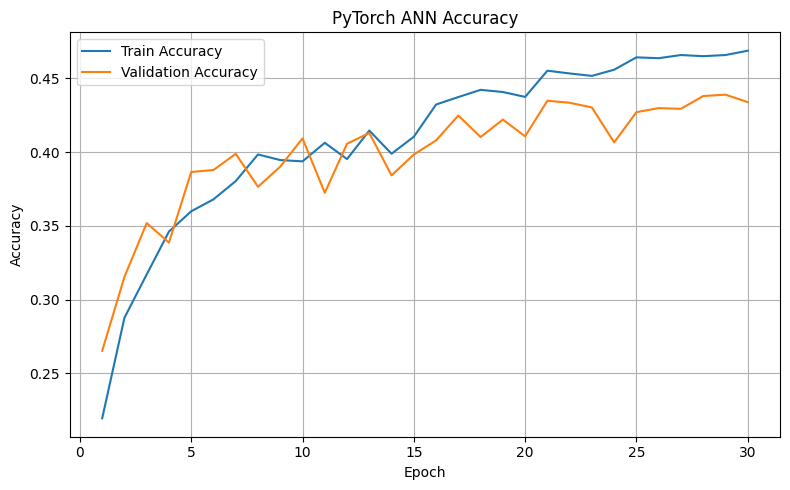

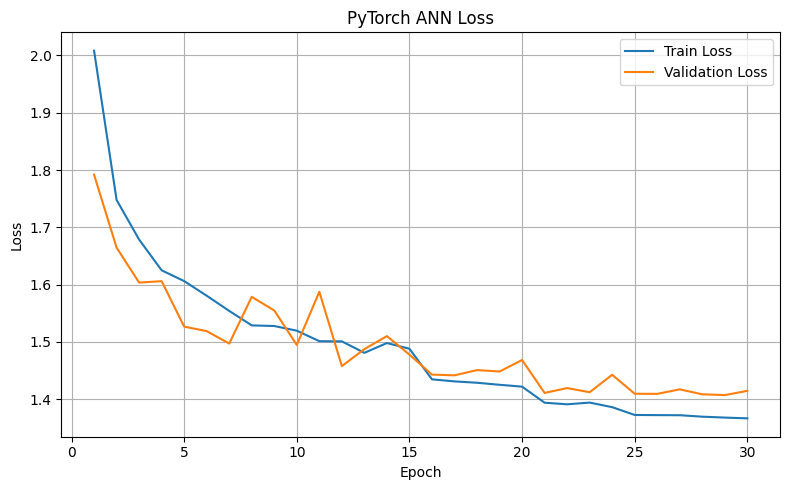

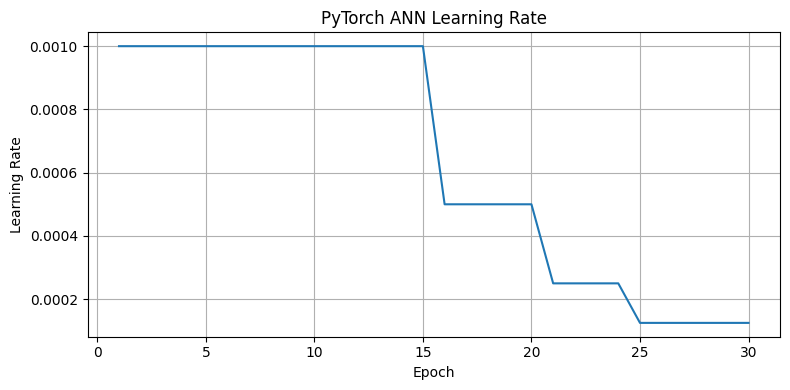

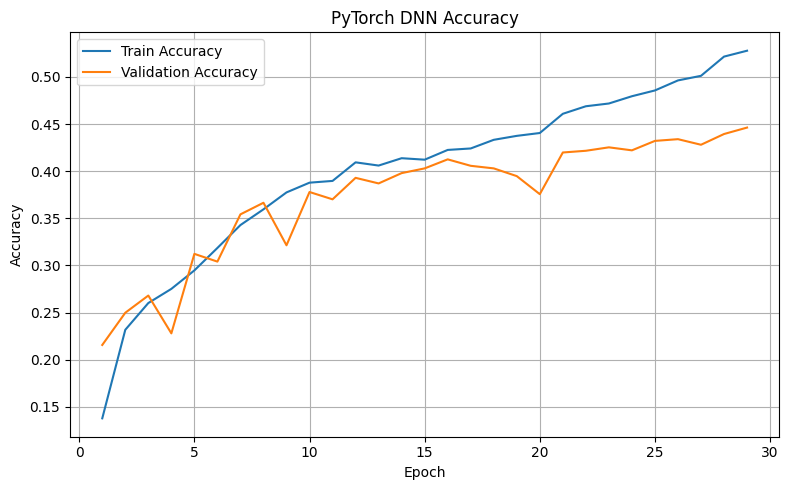

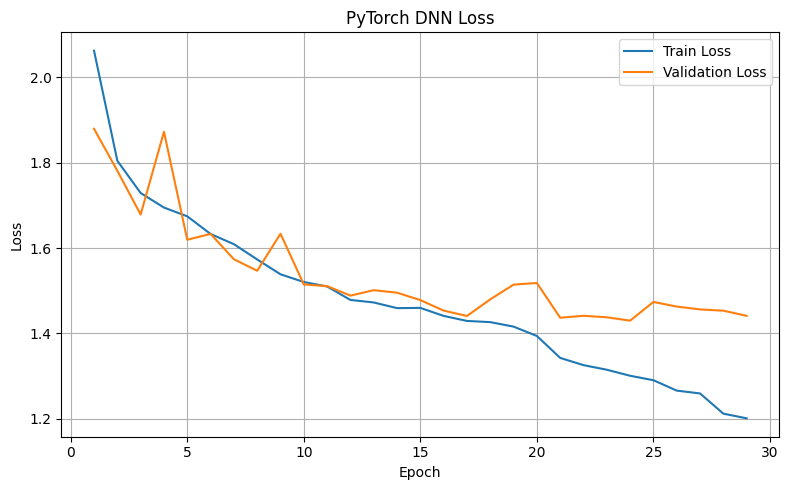

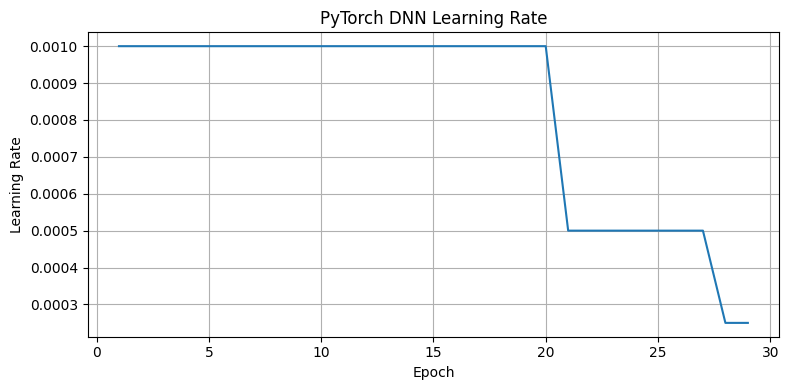

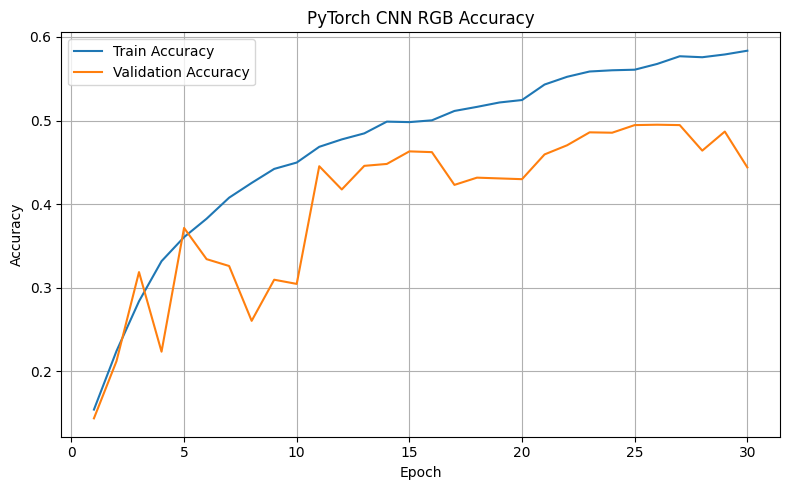

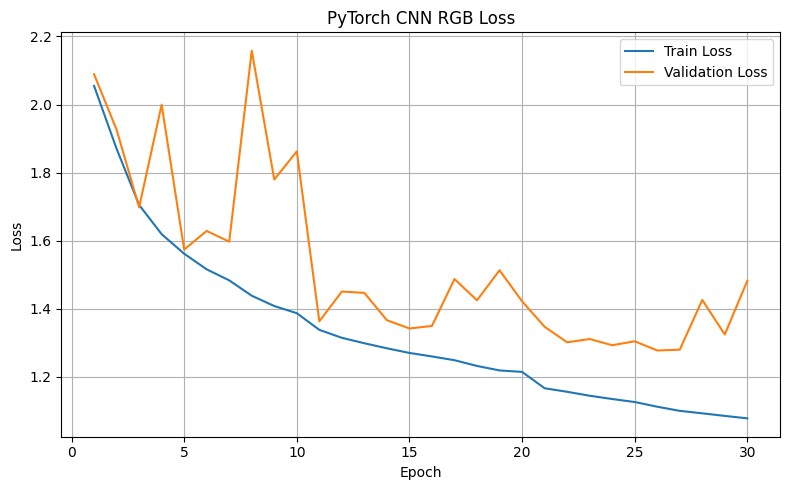

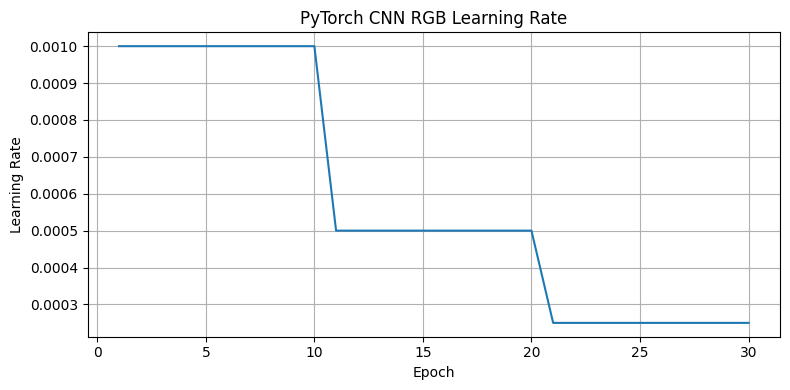

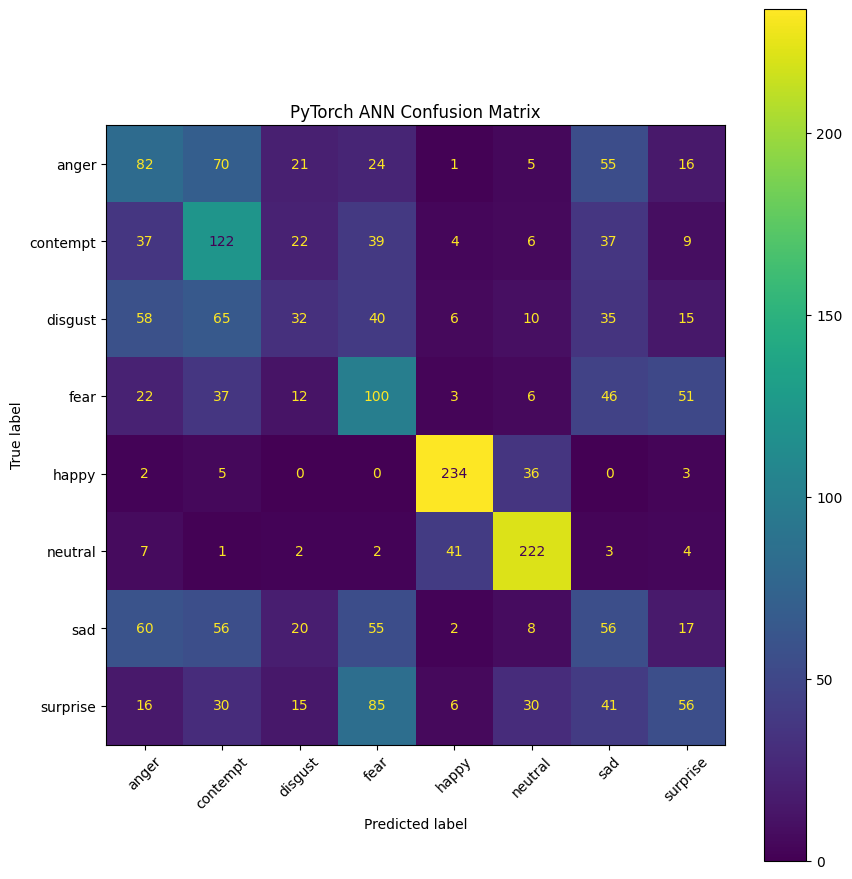

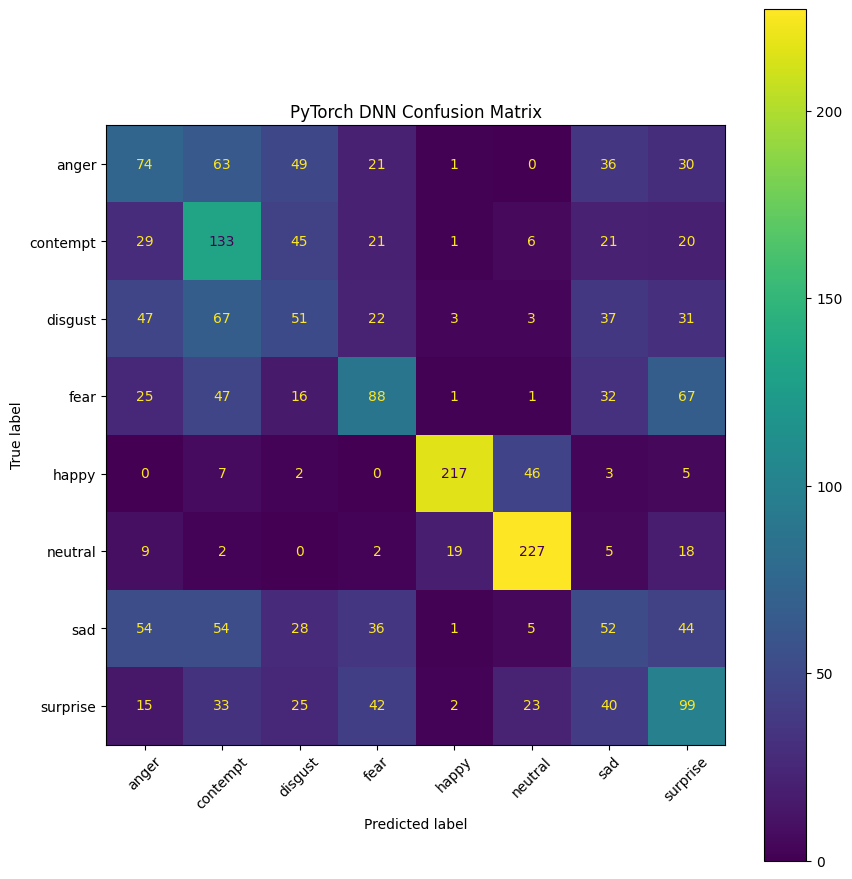

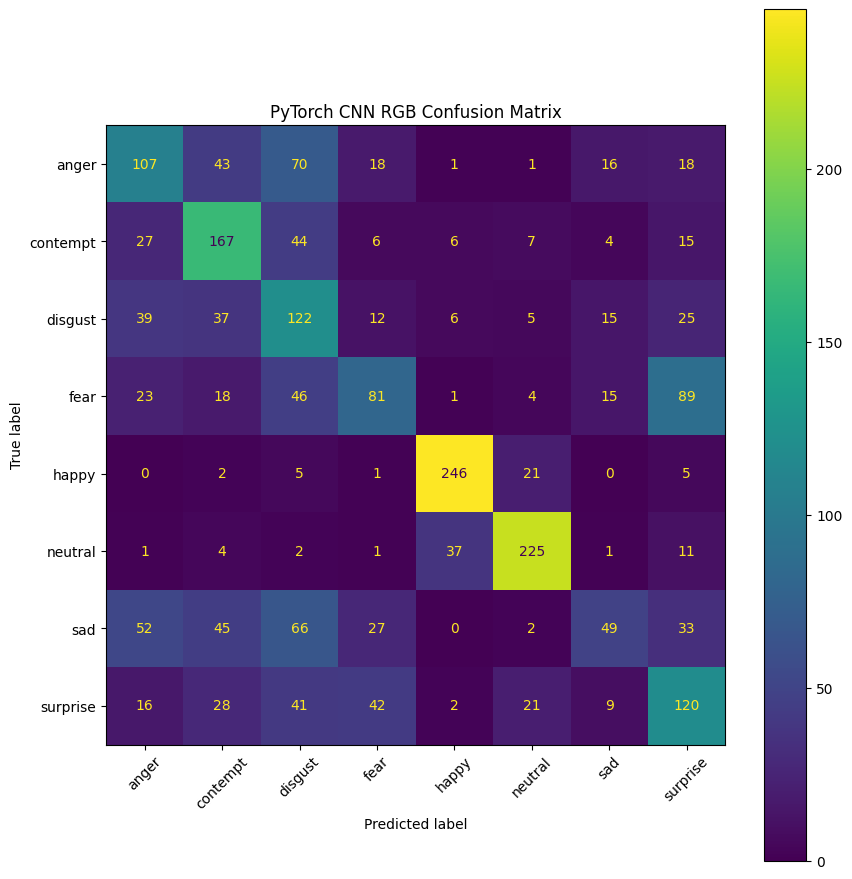



PyTorch ANN / DNN / CNN 최종 결과
Framework Model Input Size Color Mode    Augmentation Dropout  Batch Size Optimizer  Learning Rate  Test Loss  Accuracy  Macro F1  Parameters  Best Epoch  Best Train Accuracy  Best Validation Accuracy  Train-Val Gap  Epochs Trained
  PyTorch   ANN  128x128x1  Grayscale            None    None          32      Adam          0.001   1.456954  0.410350  0.393610     2098312          29             0.465808                  0.438924       0.026884              30
  PyTorch   DNN  128x128x1  Grayscale            None    None          32      Adam          0.001   1.454528  0.427145  0.420580     8555912          24             0.479465                  0.422060       0.057405              29
  PyTorch   CNN  128x128x3        RGB Flip + Rotation    None          32      Adam          0.001   1.283225  0.507036  0.494593      422824          26             0.567749                  0.494986       0.072763              30

최종 결과 CSV 저장 완료: /content/pytorch_outpu

In [ ]:
# ============================================================
# 어린이 얼굴 표정 이미지 분류
# PyTorch - ANN / DNN / CNN 비교
#
# Keras 실험 결과를 반영한 최종 비교 구조
#
# ANN
# - 128x128x1 Grayscale
# - Augmentation X
# - Dropout X
# - Flatten -> Linear128 -> ReLU -> Linear8
#
# DNN
# - 128x128x1 Grayscale
# - Augmentation X
# - Dropout X
# - LayerNorm 유지
# - 16384 -> 512 -> 256 -> 128 -> 8
#
# CNN
# - 128x128x3 RGB
# - Horizontal Flip + Rotation ±5°
# - Dropout X
# - BatchNorm 유지
# - Conv 32 -> 64 -> 128 -> 256
# - GAP -> Linear128 -> Linear8
#
# Callback
# - ANN/DNN: EarlyStopping 5, LR patience 2
# - CNN: EarlyStopping 7, LR patience 4
#
# [실행 전제]
# 이전 공통 코드에서 아래 변수가 만들어진 상태
# TRAIN_DIR / VAL_DIR / TEST_DIR
# ============================================================


# ============================================================
# 1. 라이브러리
# ============================================================

import os
import random
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    multilabel_confusion_matrix
)


# ============================================================
# 2. Random Seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# ============================================================
# 3. GPU 설정
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

PIN_MEMORY = torch.cuda.is_available()

print("=" * 70)
print("PyTorch 실행 환경")
print("=" * 70)

print("PyTorch Version :", torch.__version__)
print("사용 장치       :", device)

if torch.cuda.is_available():
    print("GPU 이름        :", torch.cuda.get_device_name(0))
else:
    print("GPU를 사용할 수 없습니다.")


# ============================================================
# 4. 기본 학습 설정
# ============================================================

IMG_SIZE = 128
BATCH_SIZE = 32
NUM_CLASSES = 8
EPOCHS = 30
LEARNING_RATE = 0.001

# Keras ANN / DNN 최종 조건
ANN_DNN_EARLY_STOPPING_PATIENCE = 5
ANN_DNN_LR_PATIENCE = 2

# Keras CNN 최종 RGB 실험 조건
CNN_EARLY_STOPPING_PATIENCE = 7
CNN_LR_PATIENCE = 4

# Keras min_delta=1e-4에 대응
MIN_DELTA = 1e-4

EXPECTED_CLASSES = [
    "anger",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]


# ============================================================
# 5. 데이터 경로 확인
# ============================================================

print("\n")
print("=" * 70)
print("PyTorch 학습 데이터 경로")
print("=" * 70)

print("TRAIN_DIR :", TRAIN_DIR)
print("VAL_DIR   :", VAL_DIR)
print("TEST_DIR  :", TEST_DIR)

for path_name, path in [
    ("TRAIN_DIR", TRAIN_DIR),
    ("VAL_DIR", VAL_DIR),
    ("TEST_DIR", TEST_DIR)
]:
    if not os.path.isdir(path):
        raise FileNotFoundError(
            f"{path_name} 폴더를 찾을 수 없습니다.\n"
            f"경로: {path}"
        )

print("\n데이터 경로 확인 완료")


# ============================================================
# 6. Transform
#
# ANN / DNN
#   - Grayscale
#   - Augmentation 없음
#
# CNN
#   - RGB
#   - Train에만 Horizontal Flip + Rotation ±5°
#
# ToTensor()
#   0~255 -> 0~1
# ============================================================

# ------------------------------------------------------------
# ANN / DNN용 Grayscale Transform
# ------------------------------------------------------------

gray_transform = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.Grayscale(
        num_output_channels=1
    ),

    transforms.ToTensor()
])


# ------------------------------------------------------------
# CNN Train용 RGB + Augmentation Transform
#
# ImageFolder 기본 PIL loader는 이미지를 RGB로 불러오므로
# Grayscale 변환을 넣지 않으면 3채널 RGB가 유지됨.
# ------------------------------------------------------------

cnn_train_transform = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=5,
        interpolation=transforms.InterpolationMode.BILINEAR
    ),

    transforms.ToTensor()
])


# ------------------------------------------------------------
# CNN Validation / Test용 RGB Transform
#
# Random Augmentation 적용하지 않음
# ------------------------------------------------------------

cnn_eval_transform = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor()
])


# ============================================================
# 7. Dataset 생성
#
# ANN / DNN과 CNN이 입력 채널이 다르므로
# Dataset도 분리해서 생성
# ============================================================

# ANN / DNN
gray_train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=gray_transform
)

gray_val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=gray_transform
)

gray_test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=gray_transform
)


# CNN
cnn_train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=cnn_train_transform
)

cnn_val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=cnn_eval_transform
)

cnn_test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=cnn_eval_transform
)


# ============================================================
# 8. 클래스 정보 검증
# ============================================================

class_names = gray_train_dataset.classes

print("\n")
print("=" * 70)
print("Dataset 정보")
print("=" * 70)

print("클래스 목록:")
print(class_names)

print("\nLabel Mapping:")
print(gray_train_dataset.class_to_idx)

if class_names != EXPECTED_CLASSES:
    raise ValueError(
        "\n예상 클래스 순서와 실제 클래스가 다릅니다.\n\n"
        f"예상: {EXPECTED_CLASSES}\n"
        f"실제: {class_names}"
    )

datasets_to_check = [
    gray_val_dataset,
    gray_test_dataset,
    cnn_train_dataset,
    cnn_val_dataset,
    cnn_test_dataset
]

for dataset in datasets_to_check:
    if dataset.classes != class_names:
        raise ValueError(
            "Dataset 간 클래스 순서가 서로 다릅니다."
        )

print("\n8개 클래스 및 Label 순서 정상")

print("\nTrain 이미지 수      :", len(gray_train_dataset))
print("Validation 이미지 수 :", len(gray_val_dataset))
print("Test 이미지 수       :", len(gray_test_dataset))


# ============================================================
# 9. DataLoader 생성 함수
#
# ANN / DNN 각각 동일한 Seed의 별도 Loader를 사용하여
# 가능한 한 동일한 Shuffle 조건을 유지
# ============================================================

def make_loader(
    dataset,
    shuffle,
    seed,
    num_workers=2
):
    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=PIN_MEMORY,
        generator=generator if shuffle else None,
        persistent_workers=(num_workers > 0)
    )


# ANN
ann_train_loader = make_loader(
    gray_train_dataset,
    shuffle=True,
    seed=SEED
)

ann_val_loader = make_loader(
    gray_val_dataset,
    shuffle=False,
    seed=SEED
)

ann_test_loader = make_loader(
    gray_test_dataset,
    shuffle=False,
    seed=SEED
)


# DNN
dnn_train_loader = make_loader(
    gray_train_dataset,
    shuffle=True,
    seed=SEED
)

dnn_val_loader = make_loader(
    gray_val_dataset,
    shuffle=False,
    seed=SEED
)

dnn_test_loader = make_loader(
    gray_test_dataset,
    shuffle=False,
    seed=SEED
)


# CNN
cnn_train_loader = make_loader(
    cnn_train_dataset,
    shuffle=True,
    seed=SEED
)

cnn_val_loader = make_loader(
    cnn_val_dataset,
    shuffle=False,
    seed=SEED
)

cnn_test_loader = make_loader(
    cnn_test_dataset,
    shuffle=False,
    seed=SEED
)


# ============================================================
# 10. Batch Shape 확인
# ============================================================

gray_images, gray_labels = next(
    iter(ann_train_loader)
)

rgb_images, rgb_labels = next(
    iter(cnn_train_loader)
)

print("\n")
print("=" * 70)
print("Batch Shape 확인")
print("=" * 70)

print(
    "ANN/DNN Image Batch Shape :",
    gray_images.shape
)

print(
    "CNN RGB Image Batch Shape :",
    rgb_images.shape
)

print(
    "Label Batch Shape         :",
    gray_labels.shape
)

print(
    "Grayscale Pixel MIN/MAX   :",
    gray_images.min().item(),
    gray_images.max().item()
)

print(
    "RGB Pixel MIN/MAX         :",
    rgb_images.min().item(),
    rgb_images.max().item()
)

# 정상:
#
# ANN/DNN
# torch.Size([32, 1, 128, 128])
#
# CNN
# torch.Size([32, 3, 128, 128])


# ============================================================
# 11. ANN
#
# Keras 최종 ANN과 동일한 구조
#
# 128x128x1
# ↓
# Flatten = 16,384
# ↓
# Linear 128
# ↓
# ReLU
# ↓
# Linear 8
#
# Augmentation X
# Dropout X
# ============================================================

class ANN(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                IMG_SIZE * IMG_SIZE,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                NUM_CLASSES
            )
        )


    def forward(self, x):

        return self.model(x)


# ============================================================
# 12. DNN
#
# Keras Ablation 결과 반영
#
# Dropout 모두 제거
# LayerNorm 유지
#
# 16,384
# ↓
# 512 + ReLU + LayerNorm
# ↓
# 256 + ReLU + LayerNorm
# ↓
# 128 + ReLU
# ↓
# 8
# ============================================================

class DNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Flatten(),

            # Hidden 1
            nn.Linear(
                IMG_SIZE * IMG_SIZE,
                512
            ),

            nn.ReLU(),

            # Keras LayerNormalization의 기본 epsilon=1e-3에 맞춤
            nn.LayerNorm(
                512,
                eps=1e-3
            ),

            # Hidden 2
            nn.Linear(
                512,
                256
            ),

            nn.ReLU(),

            nn.LayerNorm(
                256,
                eps=1e-3
            ),

            # Hidden 3
            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),

            # Output
            nn.Linear(
                128,
                NUM_CLASSES
            )
        )


    def forward(self, x):

        return self.model(x)


# ============================================================
# 13. CNN
#
# Keras 마지막 RGB 실험 구조 반영
#
# Input
# 3 x 128 x 128
#
# Conv32 + BN + ReLU + Pool
# ↓
# Conv64 + BN + ReLU + Pool
# ↓
# Conv128 + BN + ReLU + Pool
# ↓
# Conv256 + BN + ReLU + Pool
# ↓
# Adaptive Global Average Pool
# ↓
# Linear128 + ReLU
# ↓
# Linear8
#
# RGB O
# Augmentation O
# Dropout X
#
# BatchNorm 설정:
# Keras BatchNormalization 기본값과 최대한 유사하게
# eps=1e-3
# PyTorch momentum=0.01
# ============================================================

class CNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            # ------------------------------------------------
            # Conv Block 1
            #
            # 3 x 128 x 128
            # ↓
            # 32 x 64 x 64
            # ------------------------------------------------

            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                32,
                eps=1e-3,
                momentum=0.01
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),


            # ------------------------------------------------
            # Conv Block 2
            #
            # 32 x 64 x 64
            # ↓
            # 64 x 32 x 32
            # ------------------------------------------------

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                64,
                eps=1e-3,
                momentum=0.01
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),


            # ------------------------------------------------
            # Conv Block 3
            #
            # 64 x 32 x 32
            # ↓
            # 128 x 16 x 16
            # ------------------------------------------------

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                128,
                eps=1e-3,
                momentum=0.01
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),


            # ------------------------------------------------
            # Conv Block 4
            #
            # 128 x 16 x 16
            # ↓
            # 256 x 8 x 8
            # ------------------------------------------------

            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                256,
                eps=1e-3,
                momentum=0.01
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            )
        )


        # 256 x 8 x 8
        # ↓
        # 256 x 1 x 1
        self.global_avg_pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )


        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),

            # Dropout 없음

            nn.Linear(
                128,
                NUM_CLASSES
            )
        )


    def forward(self, x):

        x = self.features(x)

        x = self.global_avg_pool(x)

        x = self.classifier(x)

        return x


# ============================================================
# 14. 모델 생성 + GPU 이동
# ============================================================

ann = ANN().to(device)
dnn = DNN().to(device)
cnn = CNN().to(device)


# ============================================================
# 15. 모델 구조 확인
# ============================================================

print("\n")
print("=" * 70)
print("ANN 구조")
print("=" * 70)
print(ann)

print("\n")
print("=" * 70)
print("DNN 구조")
print("=" * 70)
print(dnn)

print("\n")
print("=" * 70)
print("CNN RGB 구조")
print("=" * 70)
print(cnn)


# ============================================================
# 16. Parameter 수
# ============================================================

def count_parameters(model):

    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


print("\n")
print("=" * 70)
print("Trainable Parameters")
print("=" * 70)

print(
    f"ANN Parameters : "
    f"{count_parameters(ann):,}"
)

print(
    f"DNN Parameters : "
    f"{count_parameters(dnn):,}"
)

print(
    f"CNN Parameters : "
    f"{count_parameters(cnn):,}"
)


# ============================================================
# 17. 결과 저장 폴더
# ============================================================

OUTPUT_DIR = "/content/pytorch_outputs_final"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print(
    "\n결과 저장 폴더:",
    OUTPUT_DIR
)


# ============================================================
# 18. 학습 함수
#
# 모델별로 Loader와 Callback 조건을 따로 전달
#
# PyTorch CrossEntropyLoss는 내부에서 LogSoftmax를 처리하므로
# 모델 마지막에 Softmax를 넣지 않음.
# ============================================================

def train_model(
    model,
    model_name,
    train_loader,
    val_loader,
    early_stopping_patience,
    lr_patience
):

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )


    # Keras ReduceLROnPlateau와 가능한 한 비슷하게 설정
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=lr_patience,
        threshold=MIN_DELTA,
        threshold_mode="abs",
        min_lr=1e-6
    )


    best_val_loss = float("inf")
    best_model_state = None

    best_epoch = 0
    best_train_acc = 0.0
    best_val_acc = 0.0

    patience_count = 0


    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "learning_rate": []
    }


    for epoch in range(EPOCHS):

        # ====================================================
        # TRAIN
        # ====================================================

        model.train()

        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0


        for images, labels in train_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            outputs = model(
                images
            )


            loss = criterion(
                outputs,
                labels
            )


            loss.backward()

            optimizer.step()


            train_loss_sum += (
                loss.item()
                * images.size(0)
            )


            predictions = outputs.argmax(
                dim=1
            )


            train_total += labels.size(0)

            train_correct += (
                predictions == labels
            ).sum().item()


        train_loss = (
            train_loss_sum
            / train_total
        )

        train_acc = (
            train_correct
            / train_total
        )


        # ====================================================
        # VALIDATION
        # ====================================================

        model.eval()

        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0


        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(
                    device,
                    non_blocking=True
                )

                labels = labels.to(
                    device,
                    non_blocking=True
                )


                outputs = model(
                    images
                )


                loss = criterion(
                    outputs,
                    labels
                )


                val_loss_sum += (
                    loss.item()
                    * images.size(0)
                )


                predictions = outputs.argmax(
                    dim=1
                )


                val_total += labels.size(0)

                val_correct += (
                    predictions == labels
                ).sum().item()


        val_loss = (
            val_loss_sum
            / val_total
        )

        val_acc = (
            val_correct
            / val_total
        )


        # 이번 Epoch에서 실제 사용한 LR
        current_lr = (
            optimizer.param_groups[0]["lr"]
        )


        # History
        history["train_loss"].append(
            train_loss
        )

        history["train_acc"].append(
            train_acc
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_acc"].append(
            val_acc
        )

        history["learning_rate"].append(
            current_lr
        )


        # ====================================================
        # Best Model / EarlyStopping
        #
        # Keras min_delta와 같은 의미가 되도록
        # val_loss < best_val_loss - MIN_DELTA 조건 사용
        # ====================================================

        improved = (
            val_loss
            < best_val_loss - MIN_DELTA
        )


        if improved:

            best_val_loss = val_loss

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            best_epoch = epoch + 1
            best_train_acc = train_acc
            best_val_acc = val_acc

            patience_count = 0


            save_path = os.path.join(
                OUTPUT_DIR,
                f"{model_name}_best.pt"
            )


            torch.save(
                best_model_state,
                save_path
            )

        else:

            patience_count += 1


        # ====================================================
        # Scheduler
        # ====================================================

        scheduler.step(
            val_loss
        )

        next_lr = (
            optimizer.param_groups[0]["lr"]
        )


        # ====================================================
        # Epoch 출력
        # ====================================================

        print(

            f"Epoch [{epoch + 1:02d}/{EPOCHS}] | "

            f"Train Loss: {train_loss:.4f} | "

            f"Train Acc: {train_acc:.4f} | "

            f"Val Loss: {val_loss:.4f} | "

            f"Val Acc: {val_acc:.4f} | "

            f"LR: {current_lr:.6f}"

        )


        if improved:

            print(
                f" → Best Model 저장 "
                f"(val_loss={best_val_loss:.4f})"
            )

        else:

            print(
                f" → EarlyStopping Count: "
                f"{patience_count}/"
                f"{early_stopping_patience}"
            )


        if next_lr < current_lr:

            print(
                f" → Learning Rate 감소: "
                f"{current_lr:.6f} "
                f"→ {next_lr:.6f}"
            )


        # ====================================================
        # EarlyStopping
        # ====================================================

        if (
            patience_count
            >= early_stopping_patience
        ):

            print(
                f"\nEarly Stopping: "
                f"Epoch {epoch + 1}"
            )

            break


    # ========================================================
    # Best Weight 복원
    # ========================================================

    if best_model_state is not None:

        model.load_state_dict(
            best_model_state
        )


    train_val_gap = (
        best_train_acc
        - best_val_acc
    )


    training_info = {

        "best_epoch":
            best_epoch,

        "best_val_loss":
            best_val_loss,

        "best_train_acc":
            best_train_acc,

        "best_val_acc":
            best_val_acc,

        "train_val_gap":
            train_val_gap,

        "epochs_trained":
            len(
                history["train_loss"]
            )

    }


    print("\n")
    print("=" * 70)
    print(f"{model_name} 학습 완료")
    print("=" * 70)

    print(
        f"Best Epoch              : "
        f"{best_epoch}"
    )

    print(
        f"Best Validation Loss    : "
        f"{best_val_loss:.6f}"
    )

    print(
        f"Best Train Accuracy     : "
        f"{best_train_acc:.6f}"
    )

    print(
        f"Best Validation Accuracy: "
        f"{best_val_acc:.6f}"
    )

    print(
        f"Train-Val Gap           : "
        f"{train_val_gap:.6f}"
    )


    return (
        history,
        training_info
    )


# ============================================================
# 19. ANN 학습
# ============================================================

print("\n")
print("=" * 70)
print("ANN 학습 시작")
print("=" * 70)

ann_history, ann_info = train_model(

    ann,

    "pytorch_ann",

    ann_train_loader,

    ann_val_loader,

    ANN_DNN_EARLY_STOPPING_PATIENCE,

    ANN_DNN_LR_PATIENCE
)


# ============================================================
# 20. DNN 학습
# ============================================================

print("\n")
print("=" * 70)
print("DNN 학습 시작")
print("=" * 70)

dnn_history, dnn_info = train_model(

    dnn,

    "pytorch_dnn",

    dnn_train_loader,

    dnn_val_loader,

    ANN_DNN_EARLY_STOPPING_PATIENCE,

    ANN_DNN_LR_PATIENCE
)


# ============================================================
# 21. CNN 학습
#
# Keras 최종 RGB CNN 조건
#
# EarlyStopping = 7
# LR patience   = 4
# ============================================================

print("\n")
print("=" * 70)
print("CNN RGB 학습 시작")
print("=" * 70)

cnn_history, cnn_info = train_model(

    cnn,

    "pytorch_cnn_rgb",

    cnn_train_loader,

    cnn_val_loader,

    CNN_EARLY_STOPPING_PATIENCE,

    CNN_LR_PATIENCE
)


# ============================================================
# 22. Test 평가 함수
#
# Accuracy
# Macro F1
# Test Loss
# Precision / Recall / F1
# TP / FP / FN / TN
# ============================================================

def evaluate_model(
    model,
    model_name,
    test_loader
):

    model.eval()

    criterion = nn.CrossEntropyLoss()


    test_loss_sum = 0.0
    test_total = 0

    y_true = []
    y_pred = []


    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels_device = labels.to(
                device,
                non_blocking=True
            )


            outputs = model(
                images
            )


            loss = criterion(
                outputs,
                labels_device
            )


            test_loss_sum += (
                loss.item()
                * images.size(0)
            )

            test_total += labels.size(0)


            predicted_classes = outputs.argmax(
                dim=1
            )


            y_true.extend(
                labels.numpy()
            )

            y_pred.extend(
                predicted_classes
                .cpu()
                .numpy()
            )


    test_loss = (
        test_loss_sum
        / test_total
    )


    y_true = np.array(
        y_true
    )

    y_pred = np.array(
        y_pred
    )


    accuracy = accuracy_score(
        y_true,
        y_pred
    )


    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )


    print("\n")
    print("=" * 85)
    print(model_name)
    print("=" * 85)

    print(
        f"Test Loss : "
        f"{test_loss:.6f}"
    )

    print(
        f"Accuracy  : "
        f"{accuracy:.6f}"
    )

    print(
        f"Macro F1  : "
        f"{macro_f1:.6f}"
    )


    print(
        "\nClassification Report\n"
    )

    print(

        classification_report(

            y_true,

            y_pred,

            labels=list(
                range(NUM_CLASSES)
            ),

            target_names=class_names,

            digits=4,

            zero_division=0

        )

    )


    # ========================================================
    # 클래스별 TP / FP / FN / TN
    # ========================================================

    matrices = multilabel_confusion_matrix(

        y_true,

        y_pred,

        labels=list(
            range(NUM_CLASSES)
        )

    )


    confusion_values = []


    print("\n")
    print("=" * 85)
    print("클래스별 TP / FP / FN / TN")
    print("=" * 85)


    for i, class_name in enumerate(
        class_names
    ):

        tn, fp, fn, tp = (
            matrices[i].ravel()
        )


        print(

            f"{class_name:10s} | "

            f"TP: {tp:4d} | "

            f"FP: {fp:4d} | "

            f"FN: {fn:4d} | "

            f"TN: {tn:4d}"

        )


        confusion_values.append({

            "Class":
                class_name,

            "TP":
                int(tp),

            "FP":
                int(fp),

            "FN":
                int(fn),

            "TN":
                int(tn)

        })


    confusion_df = pd.DataFrame(
        confusion_values
    )


    confusion_csv_path = os.path.join(

        OUTPUT_DIR,

        (
            f"{model_name.replace(' ', '_').lower()}"
            f"_tp_fp_fn_tn.csv"
        )

    )


    confusion_df.to_csv(
        confusion_csv_path,
        index=False
    )


    print(
        "\nTP/FP/FN/TN CSV 저장:",
        confusion_csv_path
    )


    return (

        test_loss,

        accuracy,

        macro_f1,

        y_true,

        y_pred,

        confusion_df
    )


# ============================================================
# 23. Test 평가
# ============================================================

(
    ann_test_loss,
    ann_acc,
    ann_f1,
    ann_true,
    ann_pred,
    ann_confusion
) = evaluate_model(
    ann,
    "PyTorch ANN",
    ann_test_loader
)


(
    dnn_test_loss,
    dnn_acc,
    dnn_f1,
    dnn_true,
    dnn_pred,
    dnn_confusion
) = evaluate_model(
    dnn,
    "PyTorch DNN",
    dnn_test_loader
)


(
    cnn_test_loss,
    cnn_acc,
    cnn_f1,
    cnn_true,
    cnn_pred,
    cnn_confusion
) = evaluate_model(
    cnn,
    "PyTorch CNN RGB",
    cnn_test_loader
)


# ============================================================
# 24. 학습 그래프 함수
# ============================================================

def plot_history(
    history,
    model_name
):

    epochs_range = range(
        1,
        len(
            history["train_acc"]
        ) + 1
    )


    # Accuracy
    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        epochs_range,
        history["train_acc"],
        label="Train Accuracy"
    )

    plt.plot(
        epochs_range,
        history["val_acc"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.title(
        f"{model_name} Accuracy"
    )

    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()


    # Loss
    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        epochs_range,
        history["train_loss"],
        label="Train Loss"
    )

    plt.plot(
        epochs_range,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.title(
        f"{model_name} Loss"
    )

    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()


    # Learning Rate
    plt.figure(
        figsize=(8, 4)
    )

    plt.plot(
        epochs_range,
        history["learning_rate"]
    )

    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")

    plt.title(
        f"{model_name} Learning Rate"
    )

    plt.grid()

    plt.tight_layout()
    plt.show()


# ============================================================
# 25. 학습 그래프 출력
# ============================================================

plot_history(
    ann_history,
    "PyTorch ANN"
)

plot_history(
    dnn_history,
    "PyTorch DNN"
)

plot_history(
    cnn_history,
    "PyTorch CNN RGB"
)


# ============================================================
# 26. Confusion Matrix
# ============================================================

def plot_confusion(
    y_true,
    y_pred,
    model_name
):

    cm = confusion_matrix(

        y_true,

        y_pred,

        labels=list(
            range(NUM_CLASSES)
        )

    )


    fig, ax = plt.subplots(
        figsize=(9, 9)
    )


    display = ConfusionMatrixDisplay(

        confusion_matrix=cm,

        display_labels=class_names

    )


    display.plot(

        ax=ax,

        xticks_rotation=45,

        values_format="d"

    )


    plt.title(
        f"{model_name} Confusion Matrix"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 27. Confusion Matrix 출력
# ============================================================

plot_confusion(
    ann_true,
    ann_pred,
    "PyTorch ANN"
)

plot_confusion(
    dnn_true,
    dnn_pred,
    "PyTorch DNN"
)

plot_confusion(
    cnn_true,
    cnn_pred,
    "PyTorch CNN RGB"
)


# ============================================================
# 28. 최종 결과 DataFrame
# ============================================================

pytorch_results = pd.DataFrame({

    "Framework": [
        "PyTorch",
        "PyTorch",
        "PyTorch"
    ],

    "Model": [
        "ANN",
        "DNN",
        "CNN"
    ],

    "Input Size": [
        "128x128x1",
        "128x128x1",
        "128x128x3"
    ],

    "Color Mode": [
        "Grayscale",
        "Grayscale",
        "RGB"
    ],

    "Augmentation": [
        "None",
        "None",
        "Flip + Rotation"
    ],

    "Dropout": [
        "None",
        "None",
        "None"
    ],

    "Batch Size": [
        BATCH_SIZE,
        BATCH_SIZE,
        BATCH_SIZE
    ],

    "Optimizer": [
        "Adam",
        "Adam",
        "Adam"
    ],

    "Learning Rate": [
        LEARNING_RATE,
        LEARNING_RATE,
        LEARNING_RATE
    ],

    "Test Loss": [
        ann_test_loss,
        dnn_test_loss,
        cnn_test_loss
    ],

    "Accuracy": [
        ann_acc,
        dnn_acc,
        cnn_acc
    ],

    "Macro F1": [
        ann_f1,
        dnn_f1,
        cnn_f1
    ],

    "Parameters": [
        count_parameters(ann),
        count_parameters(dnn),
        count_parameters(cnn)
    ],

    "Best Epoch": [
        ann_info["best_epoch"],
        dnn_info["best_epoch"],
        cnn_info["best_epoch"]
    ],

    "Best Train Accuracy": [
        ann_info["best_train_acc"],
        dnn_info["best_train_acc"],
        cnn_info["best_train_acc"]
    ],

    "Best Validation Accuracy": [
        ann_info["best_val_acc"],
        dnn_info["best_val_acc"],
        cnn_info["best_val_acc"]
    ],

    "Train-Val Gap": [
        ann_info["train_val_gap"],
        dnn_info["train_val_gap"],
        cnn_info["train_val_gap"]
    ],

    "Epochs Trained": [
        ann_info["epochs_trained"],
        dnn_info["epochs_trained"],
        cnn_info["epochs_trained"]
    ]
})


# ============================================================
# 29. 최종 결과 출력
# ============================================================

print("\n")
print("=" * 150)
print("PyTorch ANN / DNN / CNN 최종 결과")
print("=" * 150)

print(
    pytorch_results.to_string(
        index=False
    )
)


# ============================================================
# 30. CSV 저장
# ============================================================

RESULT_CSV = os.path.join(
    OUTPUT_DIR,
    "pytorch_results_final.csv"
)

pytorch_results.to_csv(
    RESULT_CSV,
    index=False
)

print(
    "\n최종 결과 CSV 저장 완료:",
    RESULT_CSV
)


# ============================================================
# 31. 저장 파일 확인
# ============================================================

print("\n")
print("=" * 80)
print("Best Model 저장 위치")
print("=" * 80)

print(
    "ANN :",
    os.path.join(
        OUTPUT_DIR,
        "pytorch_ann_best.pt"
    )
)

print(
    "DNN :",
    os.path.join(
        OUTPUT_DIR,
        "pytorch_dnn_best.pt"
    )
)

print(
    "CNN :",
    os.path.join(
        OUTPUT_DIR,
        "pytorch_cnn_rgb_best.pt"
    )
)

print("\n")
print("=" * 80)
print("실험 조건 요약")
print("=" * 80)

print(
    """
ANN
- Input        : 128x128x1 Grayscale
- Augmentation : X
- Dropout      : X
- LayerNorm    : X
- EarlyStop    : 5
- LR Patience  : 2

DNN
- Input        : 128x128x1 Grayscale
- Augmentation : X
- Dropout      : X
- LayerNorm    : O
- EarlyStop    : 5
- LR Patience  : 2

CNN
- Input        : 128x128x3 RGB
- Augmentation : Horizontal Flip + Rotation ±5°
- Dropout      : X
- BatchNorm    : O
- EarlyStop    : 7
- LR Patience  : 4
"""
)
